# Bimodal: KL divergence of MGD vs REG (paper figure)

KL analysis of `analyse_bm_results.ipynb` (June 2026, `KL_bimodal_paper.png`) on a sweep
launched with `launch/bimodal_sweep.sh`. Reads, per beta dir, `experiment_K_runs.pt`
(raw MGD `theta_final_mgd`) and `lam_selection.pt` (REG `theta_final_reg` for every lam
of the grid); REG is taken at the lam chosen by `select_lambda.py`.

* **KL vs ensemble mean** (the paper figure): `E_k[ KL(p_theta_bar || p_theta_k) ]`,
  `theta_bar` = mean over the K runs of the same estimator. A spread measure: bias is
  not counted.
* **KL vs truth**: `E_k[ KL(p_true || p_theta_k) ]`, includes the bias.
* Cramér–Rao: `r / (2 n1)` (to second order `KL ~ 1/2 dtheta^T Cov(phi) dtheta`).

theta are coefficients of `phi = [x, x^2/2, x^3/3, x^4/4]`; `p_theta ∝ exp(theta · phi)`.

In [11]:
import os
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.integrate import quad, simpson

from bimodal_utils import integrand     # the sampled density, for the convention check

# ── parameters ────────────────────────────────────────────────────────────
RESULTS = Path('results_bim_theta_beta')
# default: the newest sweep that has lam_selection.pt files
_sweeps = sorted(d for d in RESULTS.glob('bim_theta_beta_sweep_*') if any(d.glob('beta_*/lam_selection.pt')))
SWEEP_DIR = Path(os.environ.get('BM_SWEEP_DIR', _sweeps[-1] if _sweeps else ''))
LAM = 'selected'                 # 'selected', 'oracle', or a value of the lam grid
BETAS = None  # None = all
X_RANGE, N_GRID = (-10.0, 10.0), 8001

sel, mgd_final = [], []
for d in sorted(p for p in SWEEP_DIR.glob('beta_*') if p.is_dir()):
    if not (d / 'lam_selection.pt').exists():
        print('skipping', d.name, '(no lam_selection.pt)'); continue
    s = torch.load(d / 'lam_selection.pt', map_location='cpu', weights_only=False)
    if BETAS is not None and not np.isclose(BETAS, s['config']['beta']).any():
        continue
    e = torch.load(d / 'experiment_K_runs.pt', map_location='cpu', weights_only=False)
    # select_lambda.py solves the runs in the order of e['runs'] -> rows match
    assert e['theta_final_mgd'].shape[0] == s['theta_final_reg'].shape[0]
    sel.append(s); mgd_final.append(e['theta_final_mgd'].double().numpy())
betas = np.array([s['config']['beta'] for s in sel])
n1 = sel[0]['config']['n1']
print('SWEEP_DIR:', SWEEP_DIR, f'({len(sel)} betas)')

SWEEP_DIR: results_bim_theta_beta/bim_theta_beta_sweep_20260924_152418 (10 betas)


## KL on a grid (batched version of the June functions)

In [12]:
GRID = np.linspace(*X_RANGE, N_GRID)
PHI = np.stack([GRID, GRID**2 / 2, GRID**3 / 3, GRID**4 / 4], axis=1)      # (n_grid, 4)

def log_density(thetas):
    # normalised log p_theta on GRID, (M, n_grid); NaN rows where theta_4 >= 0 (not normalisable)
    thetas = np.atleast_2d(np.asarray(thetas, dtype=float))
    lv = thetas @ PHI.T
    m = lv.max(axis=1, keepdims=True)
    with np.errstate(over='ignore'):
        lv = lv - (m + np.log(simpson(np.exp(lv - m), x=GRID, axis=1))[:, None])
    lv[thetas[:, 3] >= 0] = np.nan
    return lv

def kl(log_p_ref, thetas, chunk=500):
    # KL(p_ref || p_theta) for every row of thetas; log_p_ref (n_grid,), may be -inf where p_ref = 0
    p = np.exp(log_p_ref)
    out = []
    for i in range(0, len(thetas), chunk):
        with np.errstate(invalid='ignore'):
            f = p * (log_p_ref - log_density(thetas[i:i + chunk]))
        out.append(simpson(np.where(p > 0, f, 0.0), x=GRID, axis=1))    # 0 log 0 := 0
    return np.concatenate(out)

# convention check: bimodal_utils.integrand (what x1 is drawn from) == p_theta* in this basis
print('KL(p_true || p_theta*)   (must be ~0)')
for s in sel:
    beta = s['config']['beta']
    Z, _ = quad(integrand, -np.inf, np.inf, args=(beta,))
    with np.errstate(divide='ignore'):
        log_p_true = np.log(integrand(GRID, beta)) - np.log(Z)
    print(f"  beta={beta:4.2f}: {kl(log_p_true, s['target_theta_phi'].numpy()[None])[0]: .2e}")

KL(p_true || p_theta*)   (must be ~0)
  beta=0.10: -3.82e-15
  beta=0.30:  2.61e-15
  beta=0.50: -3.40e-13
  beta=0.70:  1.35e-15
  beta=0.90:  2.57e-15
  beta=1.10:  3.76e-15
  beta=1.30:  1.25e-14
  beta=1.50: -1.78e-15
  beta=1.70:  9.83e-15
  beta=1.90: -5.86e-13


## KL per beta

In [13]:
def lam_of(s):
    return {'selected': s['lam_selected'], 'oracle': s['lam_oracle']}.get(LAM, LAM if not isinstance(LAM, str) else None)

rows = []
for s, mgd in zip(sel, mgd_final):
    lam = lam_of(s)
    i = s['lams'].index(float(lam))
    reg = s['theta_final_reg'][:, i].numpy()
    log_p_true = log_density(s['target_theta_phi'].numpy())[0]
    r = dict(beta=s['config']['beta'], K=len(mgd), lam=lam,
             # second-order check: KL_mean ~ 1/2 centered energy variance (select_lambda.py)
             quad_mgd=0.5 * float(s['var_energy_mgd_centered']),
             quad_reg=0.5 * float(s['var_energy_reg_centered'][i]))
    for name, th in [('mgd', mgd), ('reg', reg)]:
        r[f'{name}_mean'] = kl(log_density(th.mean(0))[0], th)
        r[f'{name}_true'] = kl(log_p_true, th)
    rows.append(r)

cr = sel[0]['theta_final_reg'].shape[-1] / (2 * n1)
avg = lambda a: np.nanmean(a)
print(f"LAM = {LAM!r}   Cramér–Rao r/(2 n1) = {cr:.1e}")
print(f"{'beta':>5} {'K':>4} {'lam':>7} | {'KL vs mean: MGD':>15} {'REG':>9} {'gain':>6} | {'1/2 VarE: MGD':>13} {'REG':>9}"
      f" | {'KL vs true: MGD':>15} {'REG':>9} | NaN")
for r in rows:
    nan = sum(np.isnan(r[k]).sum() for k in ('mgd_mean', 'reg_mean', 'mgd_true', 'reg_true'))
    print(f"{r['beta']:5.2f} {r['K']:4d} {r['lam']:7.0e} | {avg(r['mgd_mean']):15.3e} {avg(r['reg_mean']):9.3e} "
          f"{avg(r['mgd_mean']) / avg(r['reg_mean']):6.0f} | {r['quad_mgd']:13.3e} {r['quad_reg']:9.3e} | "
          f"{avg(r['mgd_true']):15.3e} {avg(r['reg_true']):9.3e} | {nan}")

LAM = 'selected'   Cramér–Rao r/(2 n1) = 2.0e-06
 beta    K     lam | KL vs mean: MGD       REG   gain | 1/2 VarE: MGD       REG | KL vs true: MGD       REG | NaN
 0.10  100   1e-04 |       1.592e-02 1.282e-04    124 |     1.643e-02 1.293e-04 |       1.600e-02 1.286e-04 | 0
 0.30  100   1e-04 |       1.799e-02 1.072e-04    168 |     1.877e-02 1.081e-04 |       1.825e-02 1.089e-04 | 0
 0.50  100   3e-05 |       2.529e-02 1.192e-04    212 |     2.631e-02 1.203e-04 |       2.536e-02 1.195e-04 | 0
 0.70  100   3e-05 |       3.324e-02 1.339e-04    248 |     3.597e-02 1.353e-04 |       3.398e-02 1.370e-04 | 0
 0.90  100   1e-05 |       4.482e-02 1.949e-04    230 |     4.798e-02 2.017e-04 |       4.573e-02 3.323e-04 | 0
 1.10  100   3e-06 |       5.538e-02 3.647e-04    152 |     6.303e-02 4.027e-04 |       5.795e-02 1.545e-03 | 0
 1.30  100   3e-06 |       6.665e-02 3.895e-04    171 |     7.747e-02 4.552e-04 |       7.036e-02 2.230e-03 | 0
 1.50  100   1e-06 |       8.577e-02 7.667e-04    112

## Paper figure (KL vs ensemble mean)

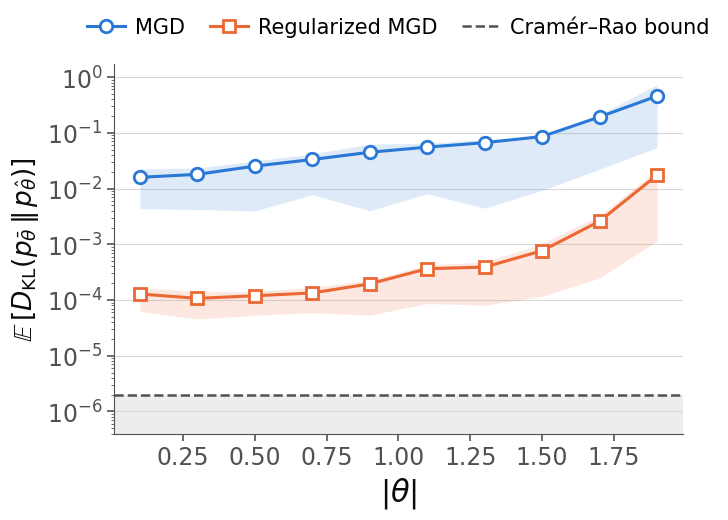

In [22]:
%matplotlib inline
C_MGD, C_REG, INK, MUTED = '#2a78d6', '#eb6834', '#0b0b0b', '#52514e'   # validated categorical slots 1-2

with plt.rc_context({'font.size': 16, 'axes.labelsize': 22, 'xtick.labelsize': 17, 'ytick.labelsize': 17,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': MUTED, 'xtick.color': MUTED, 'ytick.color': MUTED,
                     'axes.labelcolor': INK}):
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    for key, col, lab, mk in [('mgd_mean', C_MGD, 'MGD', 'o'), ('reg_mean', C_REG, 'Regularized MGD', 's')]:
        vals = [r[key][np.isfinite(r[key])] for r in rows]
        lo, hi = np.array([np.percentile(v, [25, 75]) for v in vals]).T
        ax.fill_between(betas, lo, hi, color=col, alpha=0.15, lw=0)          # spread over the K runs
        ax.plot(betas, [v.mean() for v in vals], '-' + mk, color=col, lw=2.2, ms=9,
                mfc='white', mec=col, mew=2, label=lab, zorder=3)
    ax.axhline(cr, color=MUTED, ls='--', lw=1.8, label='Cramér–Rao bound')
    ax.axhspan(cr / 100, cr, color='0.93', lw=0, zorder=0)                 # below the bound: unreachable

    ax.set_yscale('log'); ax.set_xlabel(r'$|\theta|$')        # x values are beta, label as in the paper
    ax.set_ylabel(r'$\mathbb{E}\,[D_{\rm KL}(p_{\bar\theta}\,\Vert\, p_{\hat\theta})]$', fontsize=19)
    ax.set_ylim(cr / 5, None)
    ax.tick_params(width=1.2, length=5)
    ax.grid(axis='y', which='major', color='0.85', lw=0.8); ax.set_axisbelow(True)
    # legend in one row above the axes: can never cover the data
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False,
              handlelength=1.8, columnspacing=1.2, handletextpad=0.5, fontsize=15)
    ax.axhspan(cr / 100, cr, color='0.93', lw=0, zorder=0)                 # below the bound: unreachable

    ax.set_yscale('log'); ax.set_xlabel(r'$|\theta|$')        # x values are beta, label as in the paper
    ax.set_ylabel(r'$\mathbb{E}\,[D_{\rm KL}(p_{\bar\theta}\,\Vert\, p_{\hat\theta})]$', fontsize=19)
    ax.set_ylim(cr / 5, None)
    ax.tick_params(width=1.2, length=5)
    ax.grid(axis='y', which='major', color='0.85', lw=0.8); ax.set_axisbelow(True)
    # legend in one row above the axes: can never cover the data
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False,
              handlelength=1.8, columnspacing=1.2, handletextpad=0.5, fontsize=15)
    plt.savefig("KL_bimodal_paper_1.png")
    plt.tight_layout(); plt.show()

## Same, vs the true density (bias included)

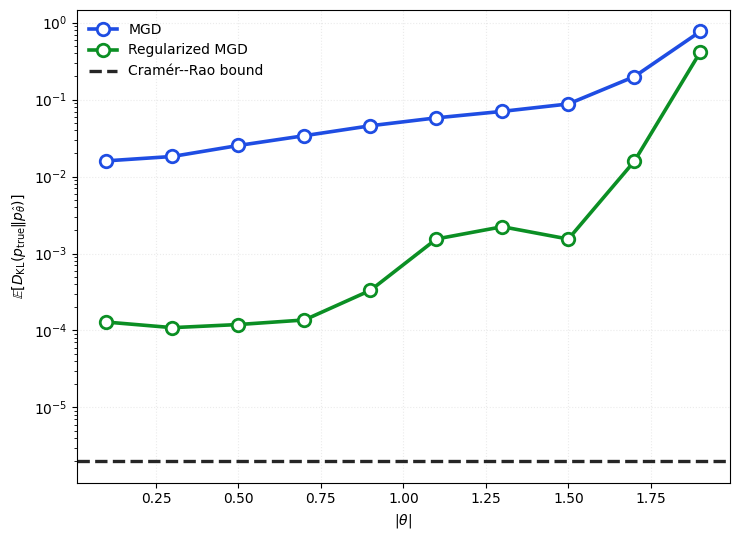

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(betas, [avg(r['mgd_true']) for r in rows], '-o', color=blue, mec=blue, label='MGD', **style)
ax.plot(betas, [avg(r['reg_true']) for r in rows], '-o', color=green, mec=green, label='Regularized MGD', **style)
ax.axhline(cr, color='0.15', ls='--', lw=2.4, label='Cramér--Rao bound')
ax.set_yscale('log'); ax.set_xlabel(r'$|\theta|$'); ax.set_ylabel(r'$\mathbb{E}[D_{\rm KL}(p_{\rm true}\Vert p_{\hat\theta})]$')
ax.grid(which='major', linestyle=':', linewidth=0.8, alpha=0.25); ax.set_axisbelow(True)
ax.legend(frameon=False); plt.tight_layout(); plt.show()